# Computer Vision (Image operators and filters)

By the end of this lab, you will get hands on experience working with:

*   Image Handling
*   Image Manipulation
*   Histogram and Histogram Equalization
*   Basic filtering techniques

<!-- ### **Remember this is a graded exercise.** -->

**Reminder**:

*   For every plot, make sure you provide appropriate titles, axis labels, legends, wherever applicable.
*   Add sufficient comments and explanations wherever necessary.

---


In [5]:
# Loading necessary libraries (Feel free to add new libraries if you need for any computation)

import numpy as np
from matplotlib import pyplot as plt
from skimage import data, exposure, filters, io, morphology 
# Loading the libraries needed for this lab.
# I keep all imports in one place so that the notebook is easier to run again later.

import os
from skimage.transform import resize

# This makes the plots appear inside the notebook.
%matplotlib inline


# Channels and color spaces

### **Exercise: Image Creation and Color Manipulation**

*   Create a 100 x 100 image for each of the below visualization

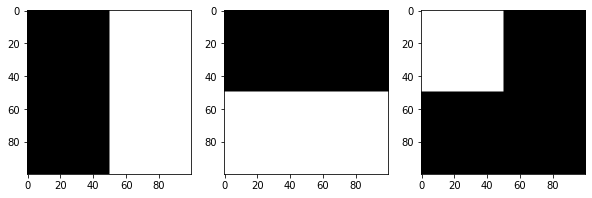

*   Visualize the created images in a 1 x 3 subplot using matplotlib.


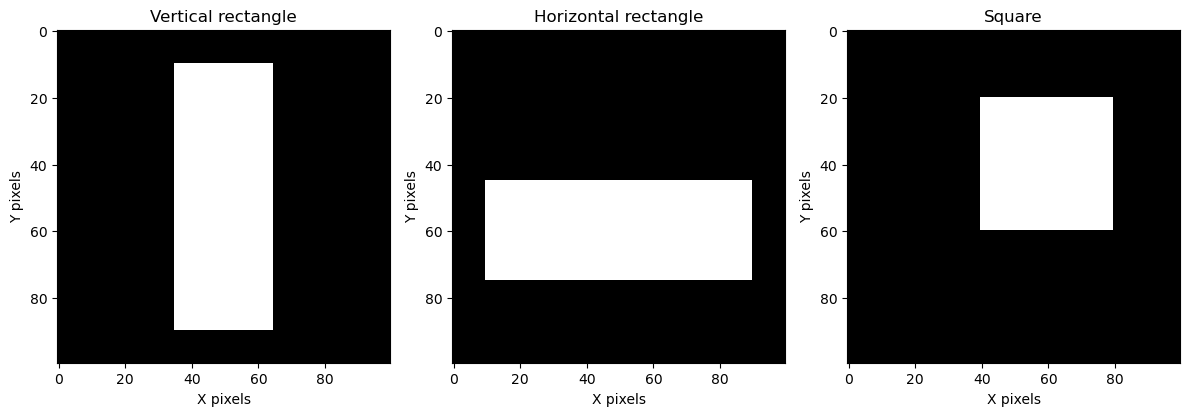

In [6]:
# solution

# Solution: create three simple 100 x 100 black-and-white images.
# Each image is a black canvas, and the white part is created by changing pixel values to 255.

height, width = 100, 100

# Image 1: vertical rectangle
vertical_img = np.zeros((height, width), dtype=np.uint8)
vertical_img[10:90, 35:65] = 255

# Image 2: horizontal rectangle
horizontal_img = np.zeros((height, width), dtype=np.uint8)
horizontal_img[45:75, 10:90] = 255

# Image 3: square
square_img = np.zeros((height, width), dtype=np.uint8)
square_img[20:60, 40:80] = 255

# Visualization in a 1 x 3 subplot
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
images = [vertical_img, horizontal_img, square_img]
titles = ["Vertical rectangle", "Horizontal rectangle", "Square"]

for ax, img, title in zip(axes, images, titles):
    ax.imshow(img, cmap="gray", vmin=0, vmax=255)
    ax.set_title(title)
    ax.set_xlabel("X pixels")
    ax.set_ylabel("Y pixels")

plt.tight_layout()
plt.show()


*   Use the above three images to create the following image

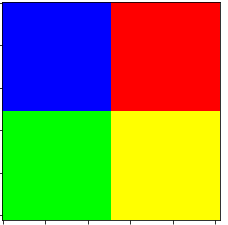
*Hint: Remember channels and color spaces*

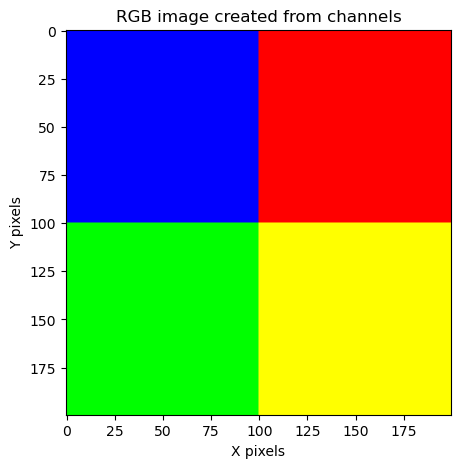

In [7]:
# solution
# Solution: create a RGB image using channels.
# A color image has 3 channels: Red, Green and Blue.
# By switching these channels on/off in different areas, we can create blue, red, green and yellow.

size = 200
red_channel = np.zeros((size, size), dtype=np.uint8)
green_channel = np.zeros((size, size), dtype=np.uint8)
blue_channel = np.zeros((size, size), dtype=np.uint8)

# Top-left: blue = only the blue channel is active
blue_channel[:100, :100] = 255

# Top-right: red = only the red channel is active
red_channel[:100, 100:] = 255

# Bottom-left: green = only the green channel is active
green_channel[100:, :100] = 255

# Bottom-right: yellow = red + green channels together
red_channel[100:, 100:] = 255
green_channel[100:, 100:] = 255

# Stack the three channels into one RGB image.
rgb_image = np.dstack((red_channel, green_channel, blue_channel))

plt.figure(figsize=(5, 5))
plt.imshow(rgb_image)
plt.title("RGB image created from channels")
plt.xlabel("X pixels")
plt.ylabel("Y pixels")
plt.show()



### **Exercise: Color Manipulation**

*   Read the image 'sillas.jpg' from the images folder

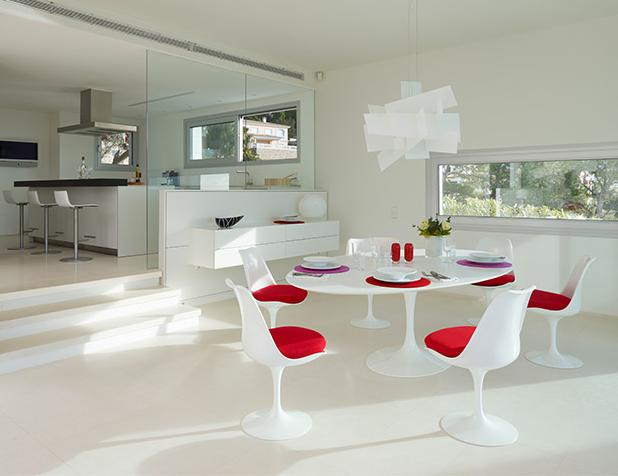

*   Extract individual channels and plot them using matplotlib subplot.



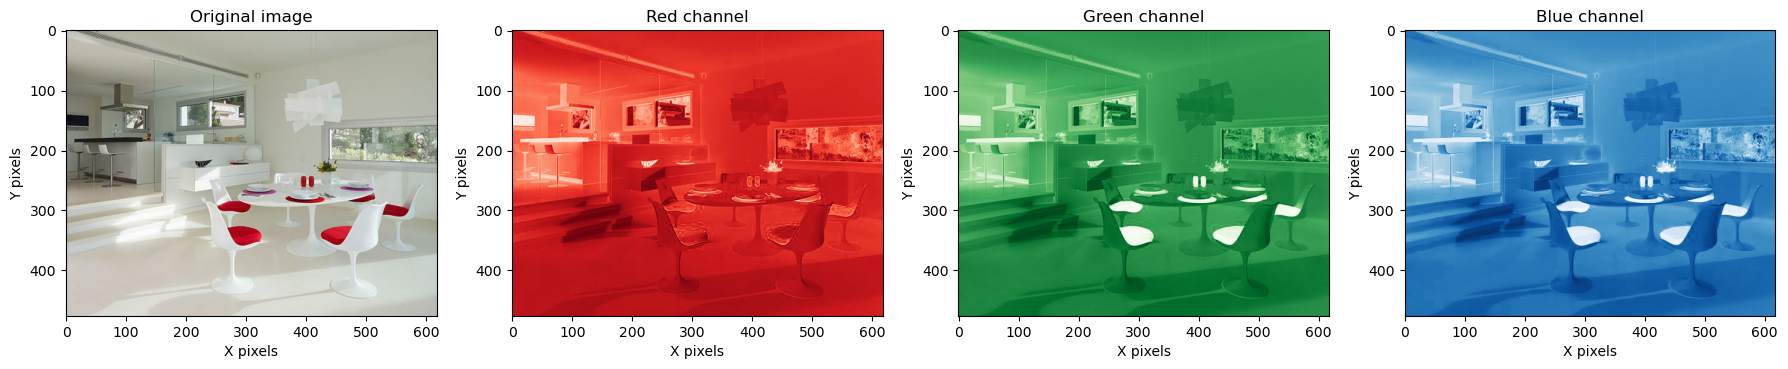

In [8]:
# solution
# Solution: read the image and separate the RGB channels.
# RGB means that the image is stored as 3 layers: Red, Green and Blue.

image_path = os.path.join("images", "sillas.jpg")
sillas = io.imread(image_path)

red = sillas[:, :, 0]
green = sillas[:, :, 1]
blue = sillas[:, :, 2]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

axes[0].imshow(sillas)
axes[0].set_title("Original image")

axes[1].imshow(red, cmap="Reds")
axes[1].set_title("Red channel")

axes[2].imshow(green, cmap="Greens")
axes[2].set_title("Green channel")

axes[3].imshow(blue, cmap="Blues")
axes[3].set_title("Blue channel")

for ax in axes:
    ax.set_xlabel("X pixels")
    ax.set_ylabel("Y pixels")

plt.tight_layout()
plt.show()



*   The color **red** looks too bright for the eyes. Isn't it?? Lets change the color and see how it appears.
    *    Create a new image where everything that is **'red' is changed to 'blue'**.
*   Visualize the original image and the created image using matplotlib subplot.

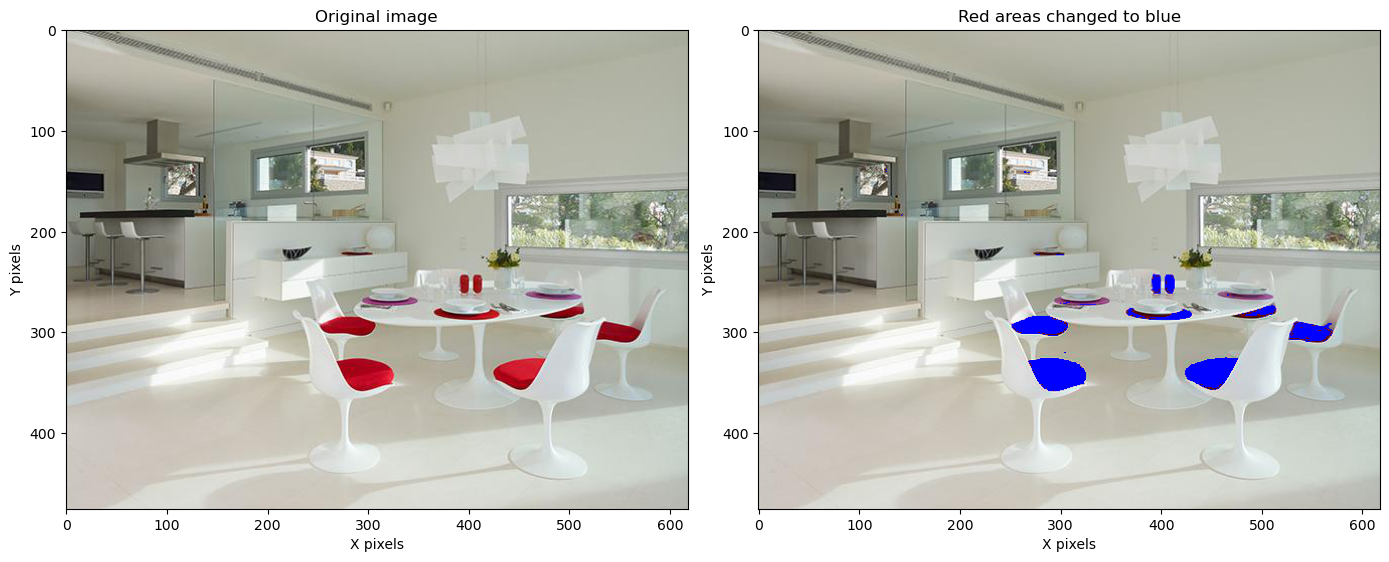

In [9]:
# solution

# Solution: change the red parts of the image to blue.
# First we create a mask that detects pixels where the red channel is much stronger
# than the green and blue channels. Then we replace those pixels with blue.

changed_image = sillas.copy()

R = changed_image[:, :, 0]
G = changed_image[:, :, 1]
B = changed_image[:, :, 2]

# This mask selects strong red areas, such as the chair cushions.
red_mask = (R > 120) & (R > G * 1.3) & (R > B * 1.3)

# Change selected red pixels to blue.
changed_image[red_mask] = [0, 0, 255]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(sillas)
axes[0].set_title("Original image")
axes[0].set_xlabel("X pixels")
axes[0].set_ylabel("Y pixels")

axes[1].imshow(changed_image)
axes[1].set_title("Red areas changed to blue")
axes[1].set_xlabel("X pixels")
axes[1].set_ylabel("Y pixels")

plt.tight_layout()
plt.show()


# Image Manipulation

### **Exercise: Image Operators**

*   You can find images 'model.png' and 'coat.png' in the images folder (First two images of the below visualization). Your task is to create an image from the given two images such a way that the model is wearing the coat (Third image in the visualization).
*   You can also find different textures in the images folder. Your task is to change the coat texture to any one of the given textures.
*   Visualize the images similar to the given visualization.

*Hint: Think masks!!!*

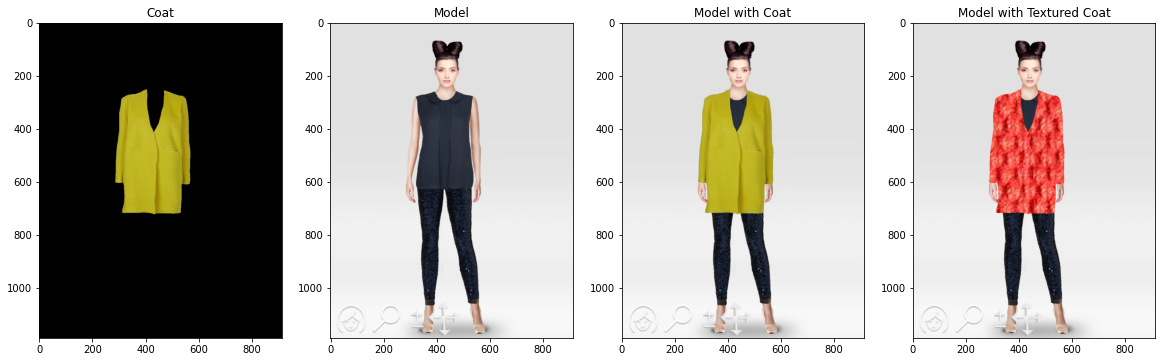

In [10]:
# solution

# Solution: use a mask to make the model wear the coat.
# The black background in coat.png is not part of the coat.
# We use it to create a mask: pixels that are not black belong to the coat.

model_path = os.path.join("images", "model.png")
coat_path = os.path.join("images", "coat.png")
texture_path = os.path.join("images", "texture_red.png")

model = io.imread(model_path)[:, :, :3]
coat = io.imread(coat_path)[:, :, :3]
texture = io.imread(texture_path)[:, :, :3]

# Make sure all images have the same size as the model.
if coat.shape[:2] != model.shape[:2]:
    coat = resize(coat, model.shape[:2], preserve_range=True, anti_aliasing=True).astype(np.uint8)

if texture.shape[:2] != model.shape[:2]:
    texture = resize(texture, model.shape[:2], preserve_range=True, anti_aliasing=True).astype(np.uint8)

# Mask: True where the coat exists, False where the background is black.
coat_mask = np.any(coat > 30, axis=2)

# Put the yellow coat over the model.
model_with_coat = model.copy()
model_with_coat[coat_mask] = coat[coat_mask]

# Replace the coat pixels with a texture.
model_with_texture = model.copy()
model_with_texture[coat_mask] = texture[coat_mask]

fig, axes = plt.subplots(1, 4, figsize=(18, 6))

axes[0].imshow(coat)
axes[0].set_title("Coat image")

axes[1].imshow(model)
axes[1].set_title("Model image")

axes[2].imshow(model_with_coat)
axes[2].set_title("Model wearing coat")

axes[3].imshow(model_with_texture)
axes[3].set_title("Coat with new texture")

for ax in axes:
    ax.set_xlabel("X pixels")
    ax.set_ylabel("Y pixels")

plt.tight_layout()
plt.show()


FileNotFoundError: No such file: '/Users/assyadahbani/lab-image-processing/images/texture_red.png'

# Contrast Enhancement

### **Exercise: Histogram Computation**

*   Read the **'astronaut' image** from data module.
*   Convert the image to grayscale.
*   Compute the **histogram of the image.** *Hint: histogram function is available in skimage.exposure package*
*   Plot the histogram using matplotlib plot.




In [11]:
# solution

# Solution: histogram computation for the astronaut image.
# A histogram counts how many pixels have each intensity value.

astronaut = data.astronaut()
astro_gray = color.rgb2gray(astronaut)

hist, bin_centers = exposure.histogram(astro_gray, nbins=256)

plt.figure(figsize=(8, 5))
plt.plot(bin_centers, hist)
plt.title("Histogram of astronaut image - 256 bins")
plt.xlabel("Pixel intensity")
plt.ylabel("Number of pixels")
plt.grid(True, alpha=0.3)
plt.show()

# Display the grayscale image too, so the histogram is easier to understand.
plt.figure(figsize=(5, 5))
plt.imshow(astro_gray, cmap="gray")
plt.title("Astronaut image in grayscale")
plt.xlabel("X pixels")
plt.ylabel("Y pixels")
plt.show()


NameError: name 'color' is not defined

*   Change the bin count to 8 and compute the histogram of the image and plot the computed histogram using matplotlib plot.

In [ ]:
# solution





*   What happens when you change the bin count? Does your inference change based on the bin count? If yes, then how do you define the correct bin count.
*   What happens when the bin count is very low and what happens when it is very high?

